In [ ]:
%pip install -q pandas matplotlib seaborn scikit-learn
print('Dependências instaladas no Kernel do Jupyter!')

# Tarefa 3 (Estudo): Árvore de Decisão Inicial
Este notebook não vai pro GitHub. É apenas para entendermos como o Scikit-Learn treina a árvore.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

# 1. Carregar os Dados da Tarefa 2
df = pd.read_csv('../data/processed/dataset_rotulado_B_split.csv')
print(f'Total de registros: {len(df)}')

Total de registros: 173674


In [2]:
%pip install scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# 2. Selecionar as Colunas Permitidas (Features)
# A professora proibiu usar IP, rota_id, fluxo_id e RTT absoluto!
features = [
    'z_robusto', 'aumento_pct', 'jitter_relativo', 'perda_pct',
    'timeout_atual', 'n5_timeout', 'n5_aumento80', 'n5_risco'
]
target = 'classe'

# 3. Separar em Treino e Validação com base na coluna de split
df_treino = df[df['split'] == 'treino']
df_val = df[df['split'] == 'validacao']

X_treino = df_treino[features].fillna(0) # Tratar vazios
y_treino = df_treino[target]

X_val = df_val[features].fillna(0)
y_val = df_val[target]

print(f'Treinando com {len(X_treino)} exemplos e validando com {len(X_val)}')

Treinando com 86822 exemplos e validando com 34703


In [4]:
# 4. Treinar a Árvore Mágica
# Vamos limitar a profundidade (max_depth) em 4 para não ficar uma árvore gigante
arvore = DecisionTreeClassifier(max_depth=4, random_state=42)
arvore.fit(X_treino, y_treino)

print('Árvore treinada com sucesso!')

Árvore treinada com sucesso!


=== BOLETIM DE NOTAS ===
              precision    recall  f1-score   support

       FALHA       1.00      0.98      0.99      2327
          OK       0.99      1.00      1.00     29675
       RISCO       0.99      0.95      0.97      2701

    accuracy                           0.99     34703
   macro avg       1.00      0.97      0.99     34703
weighted avg       0.99      0.99      0.99     34703



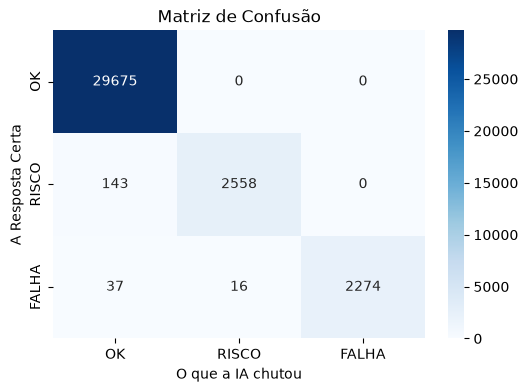

In [5]:
# 5. Avaliar o modelo (O Boletim de Notas)
previsoes = arvore.predict(X_val)

print('=== BOLETIM DE NOTAS ===')
print(classification_report(y_val, previsoes))

# Plotar a Matriz de Confusão
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, previsoes, labels=['OK', 'RISCO', 'FALHA']),
            annot=True, fmt='d', cmap='Blues', xticklabels=['OK', 'RISCO', 'FALHA'], yticklabels=['OK', 'RISCO', 'FALHA'])
plt.xlabel('O que a IA chutou')
plt.ylabel('A Resposta Certa')
plt.title('Matriz de Confusão')
plt.show()

=== COLUNAS MAIS IMPORTANTES PARA A IA ===
z_robusto          0.523578
n5_risco           0.270319
jitter_relativo    0.186231
n5_aumento80       0.015184
perda_pct          0.004688
aumento_pct        0.000000
n5_timeout         0.000000
timeout_atual      0.000000
dtype: float64


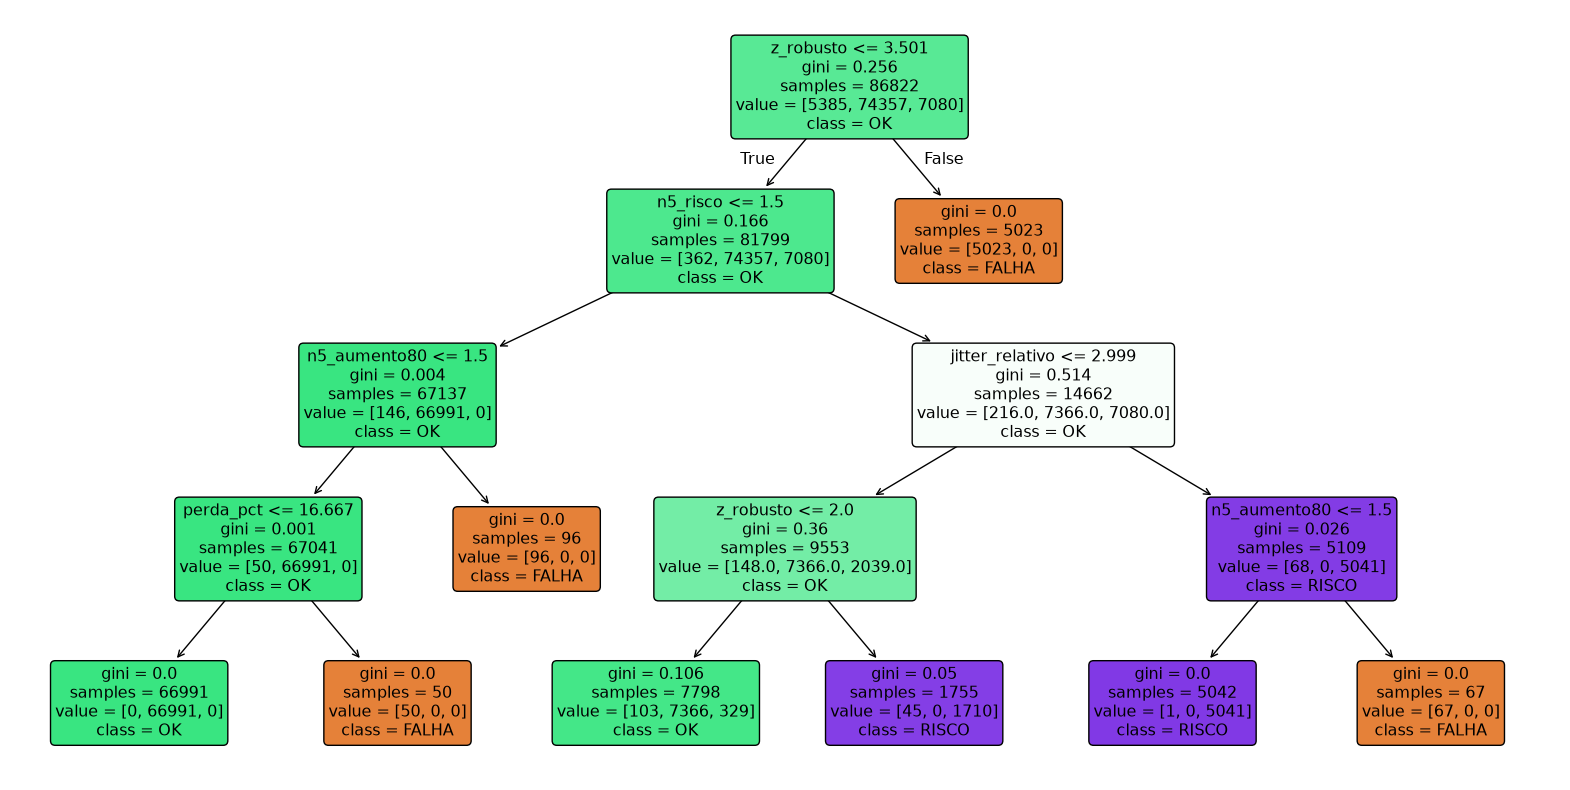

In [6]:
# 6. Ver o que a árvore achou mais importante
importancias = pd.Series(arvore.feature_importances_, index=features).sort_values(ascending=False)
print('=== COLUNAS MAIS IMPORTANTES PARA A IA ===')
print(importancias)

# Desenhar a Árvore!
plt.figure(figsize=(20,10))
plot_tree(arvore, feature_names=features, class_names=arvore.classes_, filled=True, rounded=True)
plt.show()